## Proof of Concept — Генерация метрик удобства жилья через агентную симуляцию

---

## Задача

Смоделировать поведение трёх типов агентов в **7 планировках квартир** (RPLAN-совместимый формат)  
и вычислить 4 метрики удобства: **Daily Distance, Number of Transitions, Average Path Length, Friction Score**.

## Архитектура модели

```
Планировка (граф комнат)  →  Агент (расписание дня)  →  Симуляция (Дейкстра)  →  Метрики
```

- **Планировка** — взвешенный граф: вершины = комнаты, рёбра = двери с расстоянием между центроидами.
- **Агент** — набор типичных переходов за день + параметры штрафов.
- **Путь** — кратчайший по алгоритму Дейкстры.
- **Метрики** — считаются по итогам всех переходов за день.

## Формула Friction Score

```
friction = Σ_trips [ raw_distance(trip) × speed_factor ]
         + Σ_trips [ max(0, raw_dist − threshold) × penalty_mult × speed_factor ]
         + n_transitions × transition_penalty
         + n_conflicts × 3.0     ← только для пары
```

| Параметр | Пожилой | Пара | Фрилансер |
|---|---|---|---|
| `speed_factor` | **1.5** | 1.0 | 1.0 |
| `long_path_threshold` | **5.0** | 6.0 | 6.0 |
| `long_path_penalty_mult` | **2.0** | 1.0 | 1.2 |
| `transition_penalty` | **0.5**/переход | 0 | 0 |
| `conflict_penalty_weight` | — | **3.0**/конфликт | — |

---
## Подключение реального датасета HouseExpo (при наличии доступа)


In [15]:
# from data.houseexpo_loader import load_dataset, inspect_json
#
# HOUSEEXPO_JSON_DIR = "./HouseExpo/json/"
#
# import glob, os
# sample = glob.glob(os.path.join(HOUSEEXPO_JSON_DIR, "*.json"))[0]
# inspect_json(sample)
#
# FLOORPLANS = load_dataset(HOUSEEXPO_JSON_DIR, n=7, min_rooms=4, max_rooms=9)

print("Сейчас используются синтетические планировки (RPLAN-совместимые).")

Сейчас используются синтетические планировки (RPLAN-совместимые).


---
## 0. Установка зависимостей

In [16]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import math
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import networkx as nx
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 60)

from data.floorplans import FLOORPLANS
from agents import ELDERLY, COUPLE_A, COUPLE_B, BACHELOR, ALL_AGENTS
from simulation import simulate_floorplan, run_all, build_graph, dijkstra
from metrics import results_to_dataframe, add_comfort_score, floorplan_ranking

print(f'Загружено планировок: {len(FLOORPLANS)}')
print(f'Агентов: {len(ALL_AGENTS)} типов')
print('\nПланировки:')
for fid, fp in FLOORPLANS.items():
    print(f'  • {fid}: {fp["description"]} | комнат: {len(fp["rooms"])} | соединений: {len(fp["edges"])}')

Загружено планировок: 7
Агентов: 4 типов

Планировки:
  • apt_01_1br_linear: 1-bedroom linear layout, 38m² | комнат: 5 | соединений: 4
  • apt_02_2br_corridor: 2-bedroom with central corridor, 55m² | комнат: 7 | соединений: 7
  • apt_03_studio: Studio / open-plan, 28m² | комнат: 4 | соединений: 3
  • apt_04_2br_study: 2-bedroom + study, awkward layout, 65m² | комнат: 7 | соединений: 9
  • apt_05_3br_efficient: 3-bedroom family flat, efficient hub layout, 80m² | комнат: 8 | соединений: 7
  • apt_06_1br_balcony: 1-bedroom + balcony, bathroom behind bedroom, 44m² | комнат: 6 | соединений: 5
  • apt_07_2br_2bath: 2-bedroom with 2 bathrooms, well-connected, 72m² | комнат: 7 | соединений: 9


---
## 1. Визуализация планировок как графов

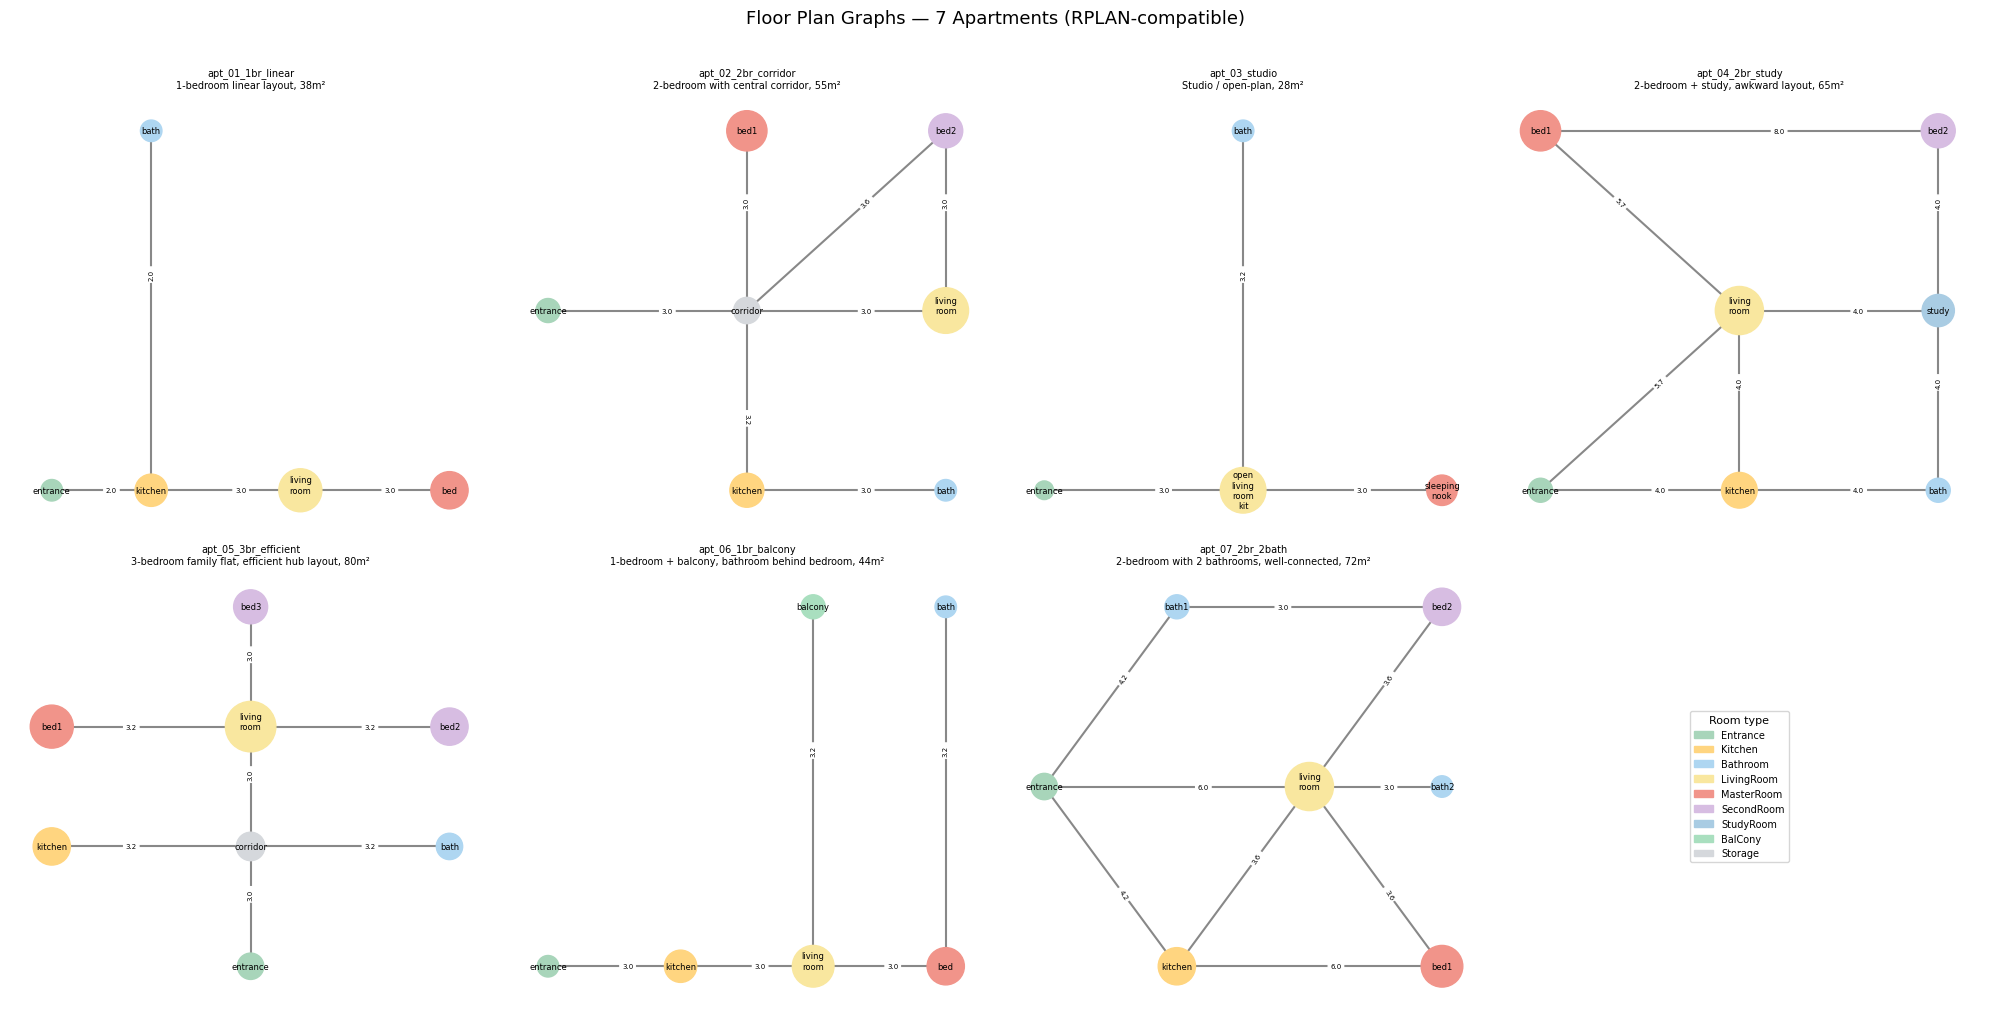

In [18]:
ROOM_COLORS = {
    'Entrance':   '#A8D5BA',
    'Kitchen':    '#FFD580',
    'Bathroom':   '#AED6F1',
    'LivingRoom': '#F9E79F',
    'MasterRoom': '#F1948A',
    'SecondRoom': '#D7BDE2',
    'StudyRoom':  '#A9CCE3',
    'BalCony':    '#A9DFBF',
    'Storage':    '#D5D8DC',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (fid, fp) in enumerate(FLOORPLANS.items()):
    ax = axes[idx]
    G = nx.Graph()

    for room_id, meta in fp['rooms'].items():
        G.add_node(room_id, pos=meta['centroid'], room_type=meta['type'], area=meta['area'])

    for (u, v, d) in fp['edges']:
        G.add_edge(u, v, weight=d)

    pos = {room_id: meta['centroid'] for room_id, meta in fp['rooms'].items()}
    node_colors = [ROOM_COLORS.get(fp['rooms'][n]['type'], '#CCCCCC') for n in G.nodes()]
    node_sizes  = [fp['rooms'][n]['area'] * 60 for n in G.nodes()]

    short_labels = {n: n.replace('_', '\n').replace('room', '').replace('living', 'living\nroom') for n in G.nodes()}

    nx.draw_networkx(G, pos=pos, ax=ax,
                     node_color=node_colors,
                     node_size=node_sizes,
                     labels=short_labels,
                     font_size=6,
                     edge_color='#888888',
                     width=1.5)

    edge_labels = {(u, v): f'{d:.1f}' for u, v, d in fp['edges']}
    nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels,
                                  font_size=5, ax=ax, label_pos=0.4)

    ax.set_title(f'{fid}\n{fp["description"]}', fontsize=7, pad=4)
    ax.axis('off')

legend_patches = [mpatches.Patch(color=c, label=t) for t, c in ROOM_COLORS.items()]
axes[-1].legend(handles=legend_patches, loc='center', fontsize=7, title='Room type', title_fontsize=8)
axes[-1].axis('off')

fig.suptitle('Floor Plan Graphs — 7 Apartments (RPLAN-compatible)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/floorplan_graphs.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. Демонстрация алгоритма Дейкстры

Показываем кратчайший путь на примере одной планировки.

In [19]:
demo_fp_id = 'apt_04_2br_study'
demo_fp    = FLOORPLANS[demo_fp_id]
demo_graph = build_graph(demo_fp)

# Три примера маршрутов
demo_paths = [
    ('bedroom1',  'bathroom',  'Пожилой: спальня → ванная'),
    ('study',     'kitchen',   'Фрилансер: кабинет → кухня'),
    ('entrance',  'bedroom2',  'Пара: вход → спальня 2'),
]

print(f'Планировка: {demo_fp_id} — {demo_fp["description"]}\n')
print(f'{"Маршрут":<35} {"Путь":<55} {"Расстояние":>12}')
for src, dst, label in demo_paths:
    dist, path = dijkstra(demo_graph, src, dst)
    path_str = ' → '.join(path) if path else 'нет пути'
    print(f'{label:<35} {path_str:<55} {dist:>10.2f}')

Планировка: apt_04_2br_study — 2-bedroom + study, awkward layout, 65m²

Маршрут                             Путь                                                      Расстояние
Пожилой: спальня → ванная           bedroom1 → living_room → kitchen → bathroom                  13.70
Фрилансер: кабинет → кухня          study → bathroom → kitchen                                    8.00
Пара: вход → спальня 2              entrance → living_room → study → bedroom2                    13.70


---
## 3. Полная симуляция

In [20]:
all_results = run_all(FLOORPLANS)

df = results_to_dataframe(all_results)
df = add_comfort_score(df)

print(f'  Строк данных: {len(df)}')
print(f'  Планировок: {df["floorplan"].nunique()}')
print(f'  Агентов: {df["agent"].nunique()}')
display(df[['floorplan','agent','daily_distance','n_transitions','avg_path_length','friction_score','comfort_score']].head(12))

  Строк данных: 21
  Планировок: 7
  Агентов: 3


,floorplan,agent,daily_distance,n_transitions,avg_path_length,friction_score,comfort_score
0,apt_01_1br_linear,Elderly (70+),42.00,16.00,4.67,83.00,72.70
1,apt_01_1br_linear,Young Couple (avg),30.00,12.00,4.29,36.00,72.40
2,apt_01_1br_linear,Remote-worker Bachelor,96.00,34.00,6.00,108.00,68.30
3,apt_02_2br_corridor,Elderly (70+),61.20,20.00,6.80,156.40,51.40
4,apt_02_2br_corridor,Young Couple (avg),46.00,15.00,6.57,57.50,55.90
5,apt_02_2br_corridor,Remote-worker Bachelor,118.00,36.00,7.38,148.00,58.10
6,apt_03_studio,Elderly (70+),18.60,6.00,3.72,34.50,100.00
7,apt_03_studio,Young Couple (avg),15.50,5.00,5.17,15.90,100.00
8,apt_03_studio,Remote-worker Bachelor,34.00,11.00,5.67,35.20,100.00
9,apt_04_2br_study,Elderly (70+),62.80,14.00,6.98,163.60,50.00


---
## 4. Детальный лог: пожилой агент в лучшей и худшей планировках

In [22]:
elderly_df = df[df['agent'] == 'Elderly (70+)'].copy()
best_fp  = elderly_df.loc[elderly_df['friction_score'].idxmin(), 'floorplan']
worst_fp = elderly_df.loc[elderly_df['friction_score'].idxmax(), 'floorplan']

print('Для пожилого агента:')
print('  Лучшая планировка: ', best_fp)
print('  Худшая планировка: ', worst_fp)

HDR  = f"  {'Действие':<25} {'Маршрут':<40} {'dist':>6} {'friction':>8}"

for label, fid in [('\n ЛУЧШАЯ', best_fp), ('ХУДШАЯ', worst_fp)]:
    result = next(r for r in all_results if r['floorplan_id'] == fid)
    trips  = result['elderly']['trips']
    m      = result['elderly']['metrics']
    desc   = FLOORPLANS[fid]['description']

    print(f'  {label}: {fid} — {desc}')
    dist_v = m['daily_distance']
    tr_v   = m['n_transitions']
    ap_v   = m['avg_path_length']
    fr_v   = m['friction_score']
    print(f'  Метрики: dist={dist_v:.2f}  transitions={tr_v}  avg_path={ap_v:.2f}  friction={fr_v:.2f}')
    print(HDR)
    for t in trips:
        lbl = t['label']
        if t['status'] == 'ok':
            path_str = ' -> '.join(t['path'])
            if len(path_str) > 38:
                path_str = path_str[:35] + '...'
            rd = t['raw_distance']
            tf = t['trip_friction']
            print(f'  {lbl:<25} {path_str:<40} {rd:>6.2f} {tf:>8.2f}')
        else:
            st = '[' + t['status'] + ']'
            print(f'  {lbl:<25} {st:<40}')
    print()

Для пожилого агента:
  Лучшая планировка:  apt_03_studio
  Худшая планировка:  apt_04_2br_study
  
 ЛУЧШАЯ: apt_03_studio — Studio / open-plan, 28m²
  Метрики: dist=18.60  transitions=6  avg_path=3.72  friction=34.50
  Действие                  Маршрут                                    dist friction
  breakfast                 [skipped_missing_room]                  
  morning hygiene           [skipped_missing_room]                  
  rest / TV                 bathroom -> open_living_kit                3.20     4.80
  lunch                     [skipped_missing_room]                  
  post-lunch rest           [skipped_missing_room]                  
  leave apartment           open_living_kit -> entrance                3.00     4.50
  return home               entrance -> open_living_kit                3.00     4.50
  evening hygiene           open_living_kit -> bathroom                3.20     4.80
  go to bed                 bathroom -> open_living_kit -> slee...     6.20    12.

---
## 5. Конфликты доступа у пары

In [23]:
print('Конфликты доступа к общим комнатам (пара):\n')
print(f'  {"Планировка":<28} {"Конфликтов":>12} {"Штраф":>10}')

conflict_data = []
for res in all_results:
    couple = res['couple']
    n = couple['n_conflicts']
    p = couple['conflict_penalty']
    conflict_data.append({'floorplan': res['floorplan_id'], 'n_conflicts': n, 'penalty': p})
    print(f"  {res['floorplan_id']:<28} {n:>12} {p:>10.1f}")

    if couple['conflicts']:
        for c in couple['conflicts']:
            print(f"    └ шаг {c['step']}: {c['room_type']} '{c['room']}'  "
                  f"A='{c['label_a']}' / B='{c['label_b']}'")

Конфликты доступа к общим комнатам (пара):

  Планировка                     Конфликтов      Штраф
  apt_01_1br_linear                       1        3.0
    └ шаг 5: Bathroom 'bathroom'  A='evening hygiene' / B='evening hygiene'
  apt_02_2br_corridor                     1        3.0
    └ шаг 5: Bathroom 'bathroom'  A='evening hygiene' / B='evening hygiene'
  apt_03_studio                           0        0.0
  apt_04_2br_study                        1        3.0
    └ шаг 5: Bathroom 'bathroom'  A='evening hygiene' / B='evening hygiene'
  apt_05_3br_efficient                    1        3.0
    └ шаг 5: Bathroom 'bathroom'  A='evening hygiene' / B='evening hygiene'
  apt_06_1br_balcony                      1        3.0
    └ шаг 5: Bathroom 'bathroom'  A='evening hygiene' / B='evening hygiene'
  apt_07_2br_2bath                        1        3.0
    └ шаг 5: Bathroom 'bathroom1'  A='evening hygiene' / B='evening hygiene'


---
## 6. Сводная таблица метрик

In [24]:
pivot = df.pivot_table(
    index='floorplan',
    columns='agent',
    values=['daily_distance','n_transitions','avg_path_length','friction_score','comfort_score']
).round(2)

print('Сводная таблица метрик (строки = планировки, колонки = агенты):')
display(pivot)

Сводная таблица метрик (строки = планировки, колонки = агенты):


avg_path_length                         \
agent                  Elderly (70+) Remote-worker Bachelor   
floorplan                                                     
apt_01_1br_linear               4.67                   6.00   
apt_02_2br_corridor             6.80                   7.38   
apt_03_studio                   3.72                   5.67   
apt_04_2br_study                6.98                   6.71   
apt_05_3br_efficient            6.89                   8.62   
apt_06_1br_balcony              5.42                   4.95   
apt_07_2br_2bath                6.33                   5.96   

                                        comfort_score                         \
agent                Young Couple (avg) Elderly (70+) Remote-worker Bachelor   
floorplan                                                                      
apt_01_1br_linear                  4.29         72.70                  68.30   
apt_02_2br_corridor                6.57         51.40                  58.10   
apt_03_studio                      5.17        100.00                 100.00   
apt_04_2br_study                   7.18         50.00                  60.90   
apt_05_3br_efficient               7.14         51.90                  50.00   
apt_06_1br_balcony                 5.69         63.10                  76.60   
apt_07_2br_2bath                   6.73         55.80                  66.30   

                                        daily_distance                         \
agent                Young Couple (avg)  Elderly (70+) Remote-worker Bachelor   
floorplan                                                                       
apt_01_1br_linear                 72.40          42.00                  96.00   
apt_02_2br_corridor               55.90          61.20                 118.00   
apt_03_studio                    100.00          18.60                  34.00   
apt_04_2br_study                  50.00          62.80                 107.40   
apt_05_3br_efficient              53.90          62.00                 138.00   
apt_06_1br_balcony                60.20          48.80                  79.20   
apt_07_2br_2bath                  54.30          57.00                  95.40   

                                        friction_score                         \
agent                Young Couple (avg)  Elderly (70+) Remote-worker Bachelor   
floorplan                                                                       
apt_01_1br_linear                 30.00          83.00                 108.00   
apt_02_2br_corridor               46.00         156.40                 148.00   
apt_03_studio                     15.50          34.50                  35.20   
apt_04_2br_study                  50.25         163.60                 135.84   
apt_05_3br_efficient              50.00         154.00                 191.76   
apt_06_1br_balcony                39.80         110.00                  83.04   
apt_07_2br_2bath                  47.10         136.90                 114.84   

                                        n_transitions                         \
agent                Young Couple (avg) Elderly (70+) Remote-worker Bachelor   
floorplan                                                                      
apt_01_1br_linear                 36.00         16.00                  34.00   
apt_02_2br_corridor               57.50         20.00                  36.00   
apt_03_studio                     15.90          6.00                  11.00   
apt_04_2br_study                  68.65         14.00                  26.00   
apt_05_3br_efficient              61.00         20.00                  44.00   
apt_06_1br_balcony                50.80         16.00                  26.00   
apt_07_2br_2bath                  60.30         14.00                  27.00   

                                         
agent                Young Couple (avg)  
floorplan                                
apt_01_1br_linear                 12.00 

---
## 7. Рейтинг планировок

In [25]:
ranking = floorplan_ranking(df)
print('Рейтинг планировок по среднему Comfort Score (100 = максимально удобно):\n')
display(ranking)
print()
print('Comfort Score = 100 / (1 + нормированный friction score)')

Рейтинг планировок по среднему Comfort Score (100 = максимально удобно):



,floorplan,description,avg_comfort_score
1,apt_03_studio,"Studio / open-plan, 28m²",100.00
2,apt_01_1br_linear,"1-bedroom linear layout, 38m²",71.10
3,apt_06_1br_balcony,"1-bedroom + balcony, bathroom behind bedroom, 44m²",66.60
4,apt_07_2br_2bath,"2-bedroom with 2 bathrooms, well-connected, 72m²",58.80
5,apt_02_2br_corridor,"2-bedroom with central corridor, 55m²",55.10
6,apt_04_2br_study,"2-bedroom + study, awkward layout, 65m²",53.60
7,apt_05_3br_efficient,"3-bedroom family flat, efficient hub layout, 80m²",51.90



Comfort Score = 100 / (1 + нормированный friction score)


---
## 8. Визуализация: Friction Score по планировкам и агентам

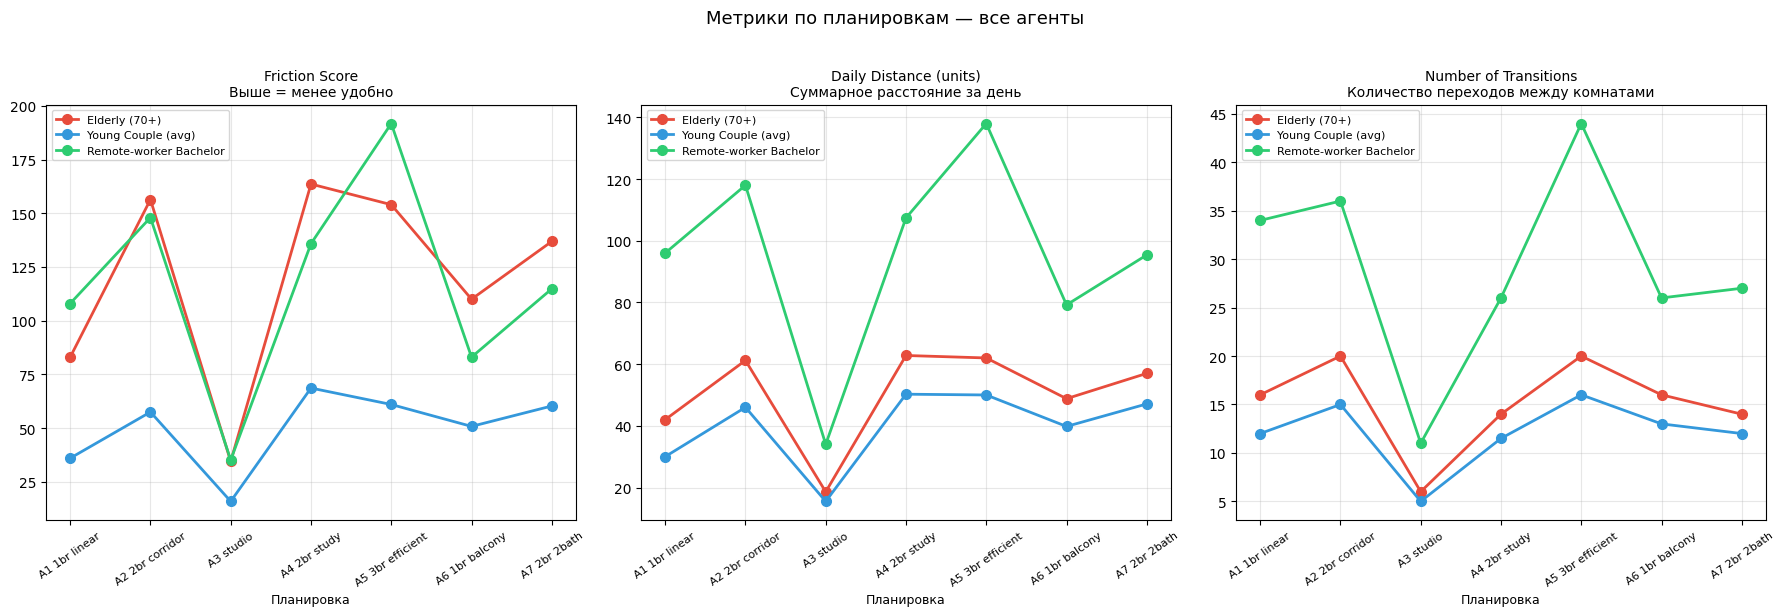

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

AGENT_COLORS = {
    'Elderly (70+)':           '#E74C3C',
    'Young Couple (avg)':      '#3498DB',
    'Remote-worker Bachelor':  '#2ECC71',
}

agents_order = ['Elderly (70+)', 'Young Couple (avg)', 'Remote-worker Bachelor']
metrics_list = [
    ('friction_score',  'Friction Score', 'Выше = менее удобно'),
    ('daily_distance',  'Daily Distance (units)', 'Суммарное расстояние за день'),
    ('n_transitions',   'Number of Transitions', 'Количество переходов между комнатами'),
]

fp_short = {fid: fid.replace('apt_0', 'A').replace('_', ' ') for fid in df['floorplan'].unique()}
df['fp_short'] = df['floorplan'].map(fp_short)

for ax, (metric, title, subtitle) in zip(axes, metrics_list):
    for agent in agents_order:
        sub = df[df['agent'] == agent].sort_values('floorplan')
        ax.plot(sub['fp_short'], sub[metric],
                marker='o', linewidth=2, markersize=7,
                label=agent, color=AGENT_COLORS[agent])

    ax.set_title(f'{title}\n{subtitle}', fontsize=10)
    ax.set_xlabel('Планировка', fontsize=9)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Метрики по планировкам — все агенты', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/metrics_by_floorplan.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Тепловая карта: Comfort Score

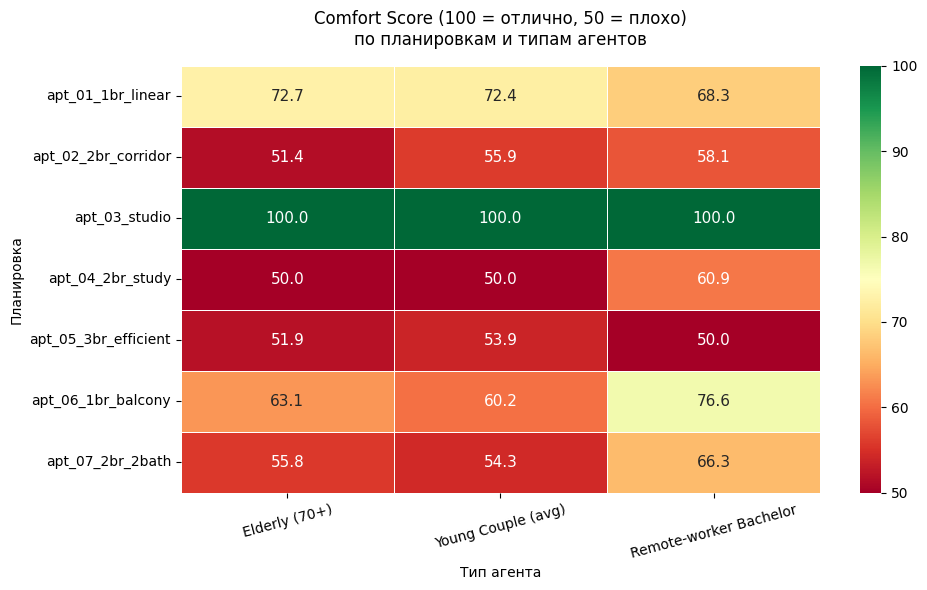

In [27]:
heat_data = df.pivot_table(index='floorplan', columns='agent', values='comfort_score')
heat_data = heat_data[agents_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heat_data, annot=True, fmt='.1f',
    cmap='RdYlGn', vmin=50, vmax=100,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 11}
)
ax.set_title('Comfort Score (100 = отлично, 50 = плохо)\nпо планировкам и типам агентов', fontsize=12, pad=15)
ax.set_xlabel('Тип агента', fontsize=10)
ax.set_ylabel('Планировка', fontsize=10)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('results/comfort_score_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 10. Разбивка Friction Score по компонентам (пожилой)

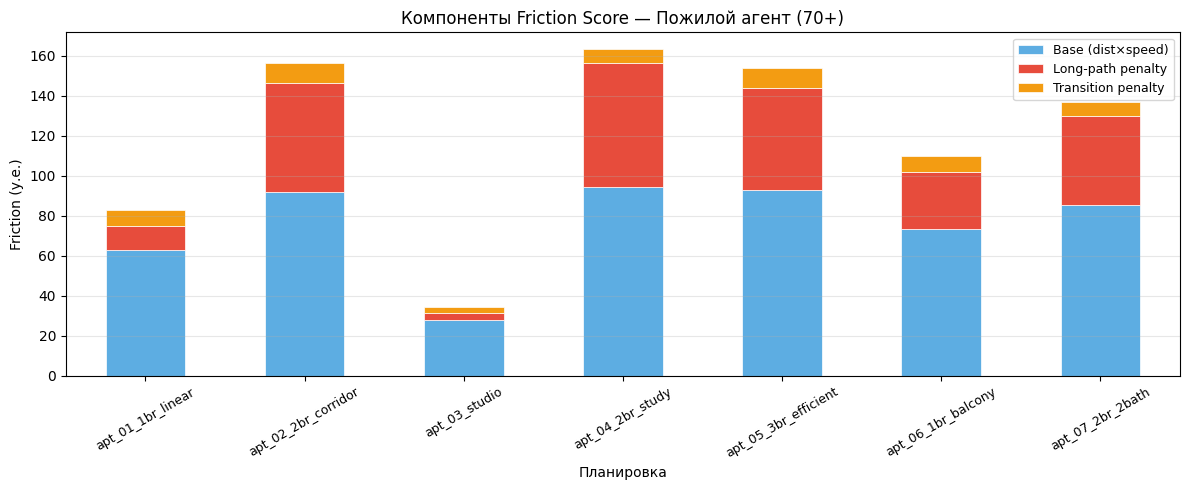

In [28]:
friction_components = []
for res in all_results:
    fid   = res['floorplan_id']
    trips = res['elderly']['trips']
    m     = res['elderly']['metrics']

    base_cost    = sum(t.get('effective_cost', 0) for t in trips if t['status'] == 'ok')
    long_penalty = sum(t.get('long_penalty', 0)   for t in trips if t['status'] == 'ok')
    trans_pen    = m.get('transition_penalty_total', 0)

    friction_components.append({
        'floorplan':       fid,
        'Base (dist×speed)': round(base_cost, 2),
        'Long-path penalty': round(long_penalty, 2),
        'Transition penalty': round(trans_pen, 2),
    })

fc_df = pd.DataFrame(friction_components).set_index('floorplan')

fig, ax = plt.subplots(figsize=(12, 5))
fc_df.plot(kind='bar', stacked=True, ax=ax,
           color=['#5DADE2', '#E74C3C', '#F39C12'],
           edgecolor='white', linewidth=0.5)

ax.set_title('Компоненты Friction Score — Пожилой агент (70+)', fontsize=12)
ax.set_xlabel('Планировка', fontsize=10)
ax.set_ylabel('Friction (у.е.)', fontsize=10)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/friction_components_elderly.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11. Average Path Length vs Daily Distance — scatter

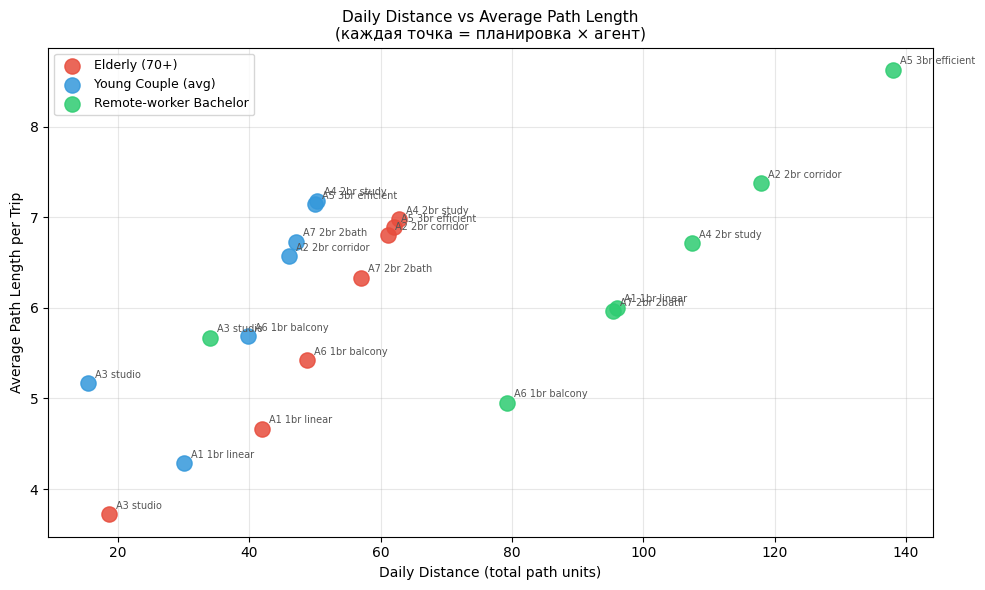

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

for agent in agents_order:
    sub = df[df['agent'] == agent]
    ax.scatter(sub['daily_distance'], sub['avg_path_length'],
               label=agent, color=AGENT_COLORS[agent],
               s=120, alpha=0.85, zorder=3)

    for _, row in sub.iterrows():
        ax.annotate(
            row['fp_short'],
            (row['daily_distance'], row['avg_path_length']),
            xytext=(5, 4), textcoords='offset points', fontsize=7, color='#555555'
        )

ax.set_xlabel('Daily Distance (total path units)', fontsize=10)
ax.set_ylabel('Average Path Length per Trip', fontsize=10)
ax.set_title('Daily Distance vs Average Path Length\n(каждая точка = планировка × агент)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/scatter_dist_vs_avgpath.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 12. Итоговое сравнение планировок

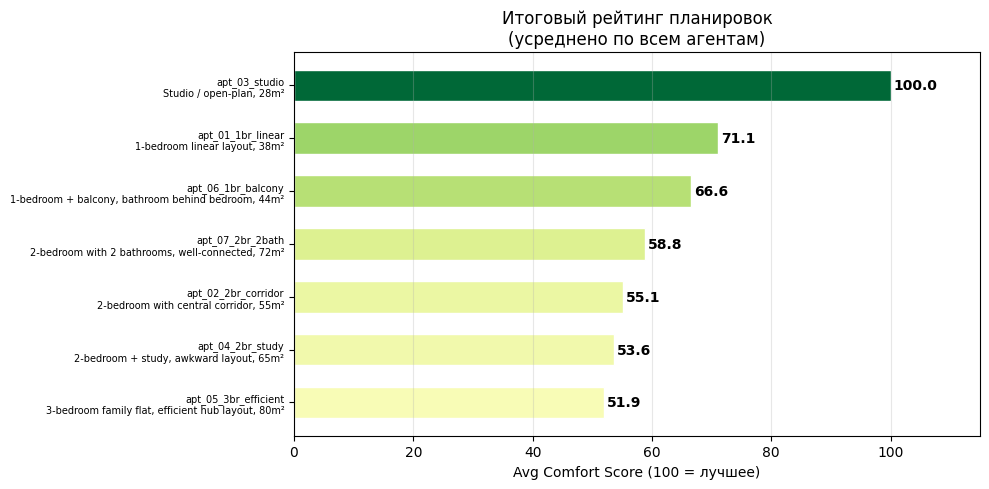


 Итоговый рейтинг:
  #1  apt_03_studio                 score=100.0  | Studio / open-plan, 28m²
  #2  apt_01_1br_linear             score= 71.1  | 1-bedroom linear layout, 38m²
  #3  apt_06_1br_balcony            score= 66.6  | 1-bedroom + balcony, bathroom behind bedroom, 44m²
  #4  apt_07_2br_2bath              score= 58.8  | 2-bedroom with 2 bathrooms, well-connected, 72m²
  #5  apt_02_2br_corridor           score= 55.1  | 2-bedroom with central corridor, 55m²
  #6  apt_04_2br_study              score= 53.6  | 2-bedroom + study, awkward layout, 65m²
  #7  apt_05_3br_efficient          score= 51.9  | 3-bedroom family flat, efficient hub layout, 80m²


In [30]:
ranking = floorplan_ranking(df)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    ranking['floorplan'][::-1],
    ranking['avg_comfort_score'][::-1],
    color=plt.cm.RdYlGn([v/100 for v in ranking['avg_comfort_score'][::-1]]),
    edgecolor='white', height=0.6
)

for bar, score in zip(bars, ranking['avg_comfort_score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlim(0, 115)
ax.set_xlabel('Avg Comfort Score (100 = лучшее)', fontsize=10)
ax.set_title('Итоговый рейтинг планировок\n(усреднено по всем агентам)', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

desc_map = {fid: f"{fid}\n{fp['description']}" for fid, fp in FLOORPLANS.items()}
ax.set_yticklabels(
    [desc_map.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()],
    fontsize=7
)

plt.tight_layout()
plt.savefig('results/floorplan_ranking.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n Итоговый рейтинг:')
for i, row in ranking.iterrows():
    print(f'  #{i}  {row["floorplan"]:<28}  score={row["avg_comfort_score"]:>5.1f}  | {row["description"]}')

---
## 13. Полный экспорт данных в CSV

In [31]:
os.makedirs('results', exist_ok=True)

df.to_csv('results/metrics_all.csv', index=False)
ranking.to_csv('results/ranking.csv', index=True)

print('  results/metrics_all.csv    — все метрики по планировкам и агентам')
print('  results/ranking.csv        — итоговый рейтинг планировок')

display(df[['floorplan','agent','daily_distance','n_transitions',
            'avg_path_length','friction_score','comfort_score']].to_string(index=False))

  results/metrics_all.csv    — все метрики по планировкам и агентам
  results/ranking.csv        — итоговый рейтинг планировок


'           floorplan                  agent  daily_distance  n_transitions  avg_path_length  friction_score  comfort_score\n   apt_01_1br_linear          Elderly (70+)           42.00          16.00             4.67           83.00          72.70\n   apt_01_1br_linear     Young Couple (avg)           30.00          12.00             4.29           36.00          72.40\n   apt_01_1br_linear Remote-worker Bachelor           96.00          34.00             6.00          108.00          68.30\n apt_02_2br_corridor          Elderly (70+)           61.20          20.00             6.80          156.40          51.40\n apt_02_2br_corridor     Young Couple (avg)           46.00          15.00             6.57           57.50          55.90\n apt_02_2br_corridor Remote-worker Bachelor          118.00          36.00             7.38          148.00          58.10\n       apt_03_studio          Elderly (70+)           18.60           6.00             3.72           34.50         100.00\n       

---
## 14. Выводы и ограничения

### Аналитические выводы

1. **Линейные планировки** (apt_01, apt_06) неудобны для пожилых:
   путь из спальни в ванную или на кухню идёт через всю квартиру, поэтому friction резко растёт.

2. **Квартиры с центральным коридором** (apt_02, apt_05) показывают лучшие результаты:
   из одного узла становятся доступны все комнаты, поэтому маршруты короткие и предсказуемые.

3. **Ванная за спальней** (apt_06) — антипаттерн:
    это длинный путь в обход для пожилого агента и дополнительные конфликты для пары.

4. **Две ванные** (apt_07) существенно снижают friction для пары:
   утренние конфликты исчезают, оба партнёра могут действовать параллельно.

5. **Фрилансер** чувствителен к расстоянию study↔kitchen и study↔bathroom:
   есть много коротких перебежек в день, поэтому неудачное расположение кабинета влияет на friction сильнее,
   чем редкие длинные маршруты.

6. **Студия** (apt_03) хороша для фрилансера и пары, потому что всё рядом,
   но плоха для пожилого, потому что нет чёткого зонирования, много пересечений потоков.

### Ограничения подхода

- **Дискретная модель**: переход = один шаг, без учёта реального времени.
- **Веса рёбер — расстояния по прямой**, реальные маршруты в комнате сложнее.
- **Конфликты пары — упрощены**: засчитываются только одновременные выходы на один шаг расписания. В реальности важна длительность пребывания в комнате.
- **Нет учёта мебели, дверных проёмов, ширины коридоров**.
- **Один день** — не учитываются выходные, болезни, гости.
- **Планировки синтетические** — структура соответствует RPLAN, но не конкретные реальные квартиры из датасета (требует доступ для скачивания).